# Stock Predictor with XGBoost

## Data collection and preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import ta
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import optuna

def load_stock_data(ticker: str, years: int = 1, end: str = None) -> pd.DataFrame:
    """
    Loads daily OHLCV data for a given stock ticker from Yahoo Finance
    for a specified number of years of historical data.

    Args:
        ticker (str): Stock ticker symbol (e.g., 'MSFT')
        years (int): Number of years of historical data to fetch (e.g., 1, 3, 5)
        end (str): End date for data (default: today, format 'YYYY-MM-DD')

    Returns:
        pd.DataFrame: Cleaned DataFrame containing stock data
    """
    end_date = pd.to_datetime(end) if end else datetime.today()
    start_date = end_date - timedelta(days=years * 365)

    print(f"Fetching {years} year(s) of data for {ticker} ({start_date.date()} - {end_date.date()})...")
    data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
    data = data.rename(columns=str.lower)

    return data

/home/teeruoko/Documents/predistocks/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ticker = "MSFT"
df = load_stock_data(ticker, years=3)

Fetching 3 year(s) of data for MSFT (2022-11-11 - 2025-11-10)...


In [3]:
def inspect_data(df: pd.DataFrame, ticker: str):
    """
    Prints key statistics and missing value summary for the given stock DataFrame.
    """
    print(f"--- {ticker} Data Overview ---")
    print(f"Date Range: {df.index.min().date()} - {df.index.max().date()}")
    print(f"Total Records: {len(df)}\n")

    print("Missing Values per Column:")
    print(df.isna().sum())
    print("\nDescriptive Statistics:")
    display(df.describe().T.round(1))

inspect_data(df, ticker)

--- MSFT Data Overview ---
Date Range: 2022-11-11 - 2025-11-07
Total Records: 750

Missing Values per Column:
Price   Ticker
close   msft      0
high    msft      0
low     msft      0
open    msft      0
volume  msft      0
dtype: int64

Descriptive Statistics:


,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
close,msft,750.0,384.8,79.5,217.5,325.4,402.1,428.9,542.1
high,msft,750.0,388.1,79.9,220.9,329.0,405.3,433.1,554.5
low,msft,750.0,381.3,79.3,214.6,322.8,398.7,425.9,540.8
open,msft,750.0,384.8,79.8,218.2,326.4,403.2,430.7,554.3
volume,msft,750.0,23634120.5,9588958.0,7164500.0,17497100.0,21224100.0,26680875.0,86102000.0


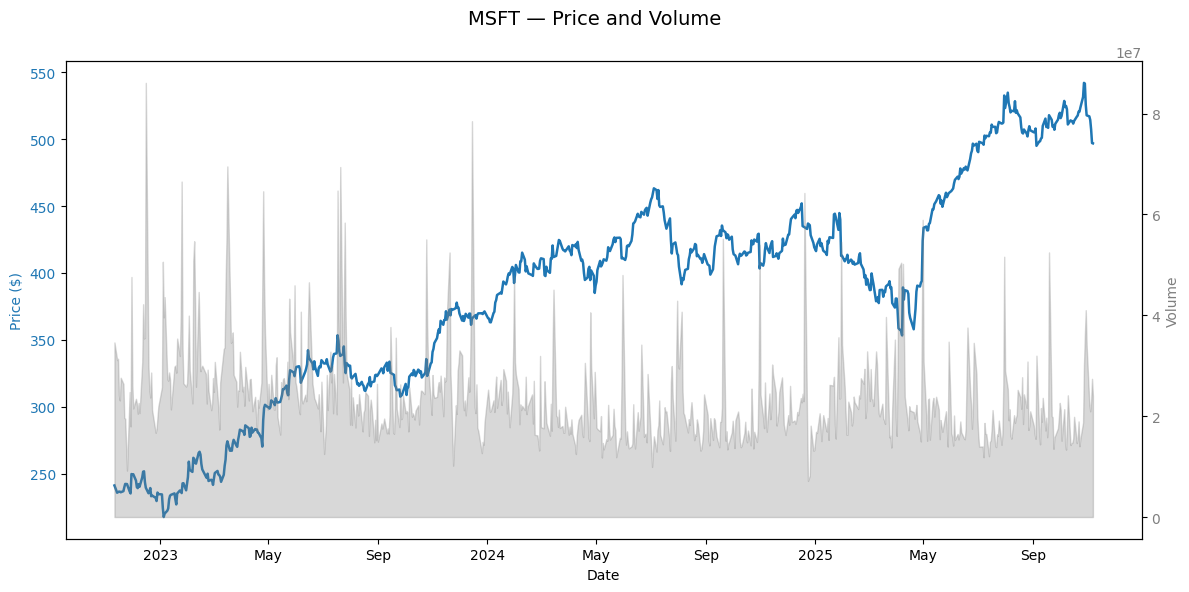

In [4]:
def plot_price_volume(df: pd.DataFrame, ticker: str):
    """
    Plots closing price and trading volume for visual inspection.
    Handles both single-level and multi-level DataFrame columns.
    """
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in df.columns]
    else:
        df.columns = [c.lower() for c in df.columns]

    close_candidates = [c for c in df.columns if "close" in c and ticker.lower() in c]
    volume_candidates = [c for c in df.columns if "volume" in c and ticker.lower() in c]

    close_col = close_candidates[0] if close_candidates else "close"
    volume_col = volume_candidates[0] if volume_candidates else "volume"

    if close_col not in df.columns or volume_col not in df.columns:
        raise ValueError(f"Could not find 'close' or 'volume' columns for {ticker}. Columns: {list(df.columns)}")

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(df.index, df[close_col], color='tab:blue', linewidth=1.8, label='Close Price')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Price ($)", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator()))

    ax2 = ax1.twinx()
    ax2.fill_between(df.index, df[volume_col], color='tab:gray', alpha=0.3)
    ax2.set_ylabel("Volume", color='tab:gray')
    ax2.tick_params(axis='y', labelcolor='tab:gray')

    fig.suptitle(f"{ticker} — Price and Volume", fontsize=14)
    fig.tight_layout()
    plt.show()

plot_price_volume(df, ticker)


In [5]:
def check_data_quality(df: pd.DataFrame):
    """
    Simple outlier detection.
    """
    numeric_cols = df.select_dtypes(include='number')
    z_scores = (numeric_cols - numeric_cols.mean()) / numeric_cols.std()
    outlier_ratio = (abs(z_scores) > 3).sum() / len(df)
    print("Potential outlier ratio per column:")
    print(outlier_ratio)

check_data_quality(df)

Potential outlier ratio per column:
Price   Ticker
close   msft      0.000
high    msft      0.000
low     msft      0.000
open    msft      0.000
volume  msft      0.024
dtype: float64


--- MSFT Daily Return Summary (in %) ---
count    749.000000
mean       0.107567
std        1.488191
min       -6.180897
0.1%      -6.085051
1%        -3.571613
50%        0.116788
99%        4.018284
99.9%      8.257454
max       10.133687
Name: daily_return_pct, dtype: float64

Total days: 749
Days with daily return within ±1%: 444 (59.3%)
Days with daily return >±1% and ≤±2%: 194 (25.9%)
Days with daily return >±2% and ≤±5%: 105 (14.0%)
Days with daily return >±5%: 6 (0.8%)


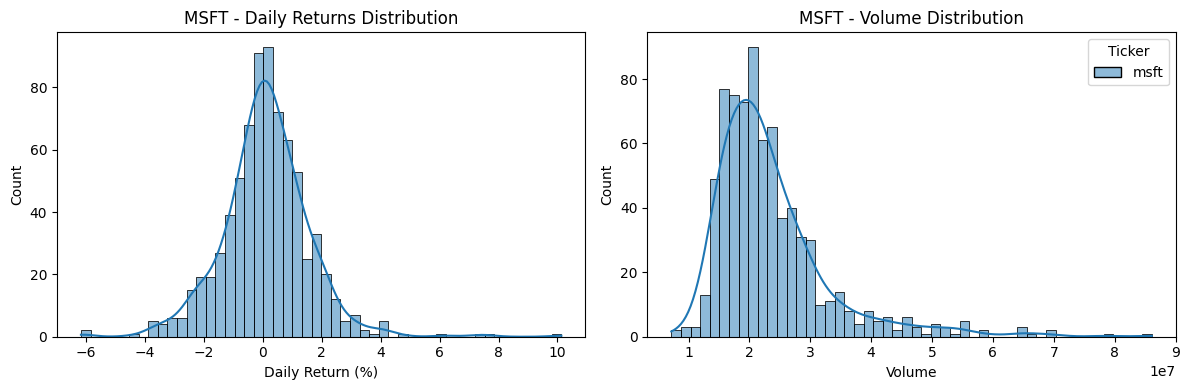

In [6]:
def plot_distributions(df: pd.DataFrame, ticker: str):
    """
    Plots histograms for price returns and volume distributions.
    Also prints descriptive statistics and counts of daily returns within specific ranges.
    """
    df = df.copy()
    df['daily_return'] = df['close'].pct_change()
    df['daily_return_pct'] = df['daily_return'] * 100
    
    print(f"--- {ticker} Daily Return Summary (in %) ---")
    print(df['daily_return_pct'].describe(percentiles=[0.001, 0.01, 0.99, 0.999]))
    
    total_days = len(df['daily_return'].dropna())
    within_1pct = ((df['daily_return'] >= -0.01) & (df['daily_return'] <= 0.01)).sum()
    between_1_2pct = (((df['daily_return'] > 0.01) & (df['daily_return'] <= 0.02)) | 
                    ((df['daily_return'] < -0.01) & (df['daily_return'] >= -0.02))).sum()
    between_2_5pct = (((df['daily_return'] > 0.02) & (df['daily_return'] <= 0.05)) | 
                    ((df['daily_return'] < -0.02) & (df['daily_return'] >= -0.05))).sum()
    above_5pct = ((df['daily_return'] > 0.05) | (df['daily_return'] < -0.05)).sum()

    print(f"\nTotal days: {total_days}")
    print(f"Days with daily return within ±1%: {within_1pct} ({within_1pct/total_days:.1%})")
    print(f"Days with daily return >±1% and ≤±2%: {between_1_2pct} ({between_1_2pct/total_days:.1%})")
    print(f"Days with daily return >±2% and ≤±5%: {between_2_5pct} ({between_2_5pct/total_days:.1%})")
    print(f"Days with daily return >±5%: {above_5pct} ({above_5pct/total_days:.1%})")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df['daily_return_pct'].dropna(), bins=50, kde=True, ax=axes[0])
    axes[0].set_title(f"{ticker} - Daily Returns Distribution")
    axes[0].set_xlabel("Daily Return (%)")
    
    sns.histplot(df['volume'].dropna(), bins=50, kde=True, ax=axes[1])
    axes[1].set_title(f"{ticker} - Volume Distribution")
    axes[1].set_xlabel("Volume")
    
    plt.tight_layout()
    plt.show()

plot_distributions(df, ticker)

## Feature engineering

In [7]:
def create_features(data: pd.DataFrame, lag: int = 3, use_ta: bool = False):
    """
    Converts OHLCV data into supervised learning features for next-day prediction.

    Args:
        data (pd.DataFrame): Daily stock data with columns ['open','high','low','close','volume']
        lag (int): Number of past days used as features
        use_ta (bool): Use TA features

    Returns:
        X (pd.DataFrame): Feature matrix
        y (pd.Series): Target values (next-day close)
    """
    df = data.copy()

    if use_ta:
        df["return"] = df["close"].pct_change()
        df["ma_5"] = df["close"].rolling(5).mean()
        df["ma_20"] = df["close"].rolling(20).mean()
        df["momentum"] = df["close"] / df["close"].shift(5) - 1
        df["volatility"] = df["return"].rolling(10).std()

        close = df["close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        rsi = ta.momentum.RSIIndicator(close.squeeze(), window=14).rsi()
        macd = ta.trend.MACD(close.squeeze()).macd()
        bb = ta.volatility.BollingerBands(close.squeeze())

        df["rsi"] = np.array(rsi).flatten()
        df["macd"] = np.array(macd).flatten()
        df["bb_high"] = np.array(bb.bollinger_hband()).flatten()
        df["bb_low"] = np.array(bb.bollinger_lband()).flatten()


    df = df.dropna()

    features = []
    targets = []
    target_dates = []
    feature_dates = []

    for i in range(lag, len(df)):
        window = df.iloc[i - lag:i]
        next_close = df.iloc[i]["close"]
        next_date = df.index[i]
        window_dates = df.index[i - lag:i]

        feat = window.values.flatten()
        features.append(feat)
        targets.append(next_close)
        target_dates.append(next_date)
        feature_dates.append(window_dates)

    X = np.array(features)
    y = np.array(targets).flatten()
    target_dates = np.array(target_dates)
    return X, y, target_dates, feature_dates

In [8]:
def walk_forward_sliding_window(X, y, target_dates, train_window=100, step=1, params=None):
    """
    Walk-forward validation with a sliding training window for next-day stock prediction.

    Args:
        X (np.ndarray): Feature matrix
        y (np.ndarray): Target vector
        target_dates (np.ndarray): Corresponding dates
        train_window (int): Number of past samples used for training at each step
        step (int): How many steps to move the window forward each iteration
        params (dict): Hyperparameters for XGBRegressor

    Returns:
        results (pd.DataFrame): DataFrame with date, actual, predicted
        metrics (dict): Overall MAE and RMSE
    """
    if params is None:
        params = {
            "n_estimators": 600,
            "learning_rate": 0.03,
            "max_depth": 5,
            "min_child_weight": 5,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "gamma": 0.2,
            "reg_lambda": 2.0,
            "reg_alpha": 0.5,
            "objective": "reg:squarederror",
            "eval_metric": "mae",
            "random_state": 42,
        }

    n_samples = len(X)
    predictions = []
    actuals = []
    dates = []

    start_idx = train_window
    for i in range(start_idx, n_samples, step):
        train_idx = slice(i - train_window, i)
        test_idx = i

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx:test_idx+1], y[test_idx:test_idx+1]

        model = XGBRegressor(**params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        dates.append(target_dates[test_idx])

    results = pd.DataFrame({
        "date": dates,
        "actual": actuals,
        "predicted": predictions
    }).set_index("date")

    mae = mean_absolute_error(results["actual"], results["predicted"])
    rmse = root_mean_squared_error(results["actual"], results["predicted"])
    r2 = r2_score(results["actual"], results["predicted"])
    mape = np.mean(np.abs((results["actual"] - results["predicted"]) / results["actual"])) * 100

    # Directional Accuracy (DA)
    actual_change = np.sign(results["actual"].diff())
    predicted_change = np.sign(results["predicted"].diff())
    da = np.mean(actual_change[1:] == predicted_change[1:]) * 100

    metrics = {
        "MAE": mae,
        "MAPE": mape,
        #"RMSE": rmse,
        "R2": r2,
        "Directional_Accuracy": da
    }

    print(f"MAE: {mae:.3f}, MAPE: {mape:.3f}%, R²: {r2:.2f}, DA: {da:.2f}%")

    return results, metrics

In [9]:
def optimize_window_sizes(data, lag_values, train_window_values, use_ta):
    """
    Simple grid search over lag and train_window sizes using walk-forward validation.

    Args:
        data (pd.DataFrame): Stock data (OHLCV)
        lag_values (list): Candidate lag values (e.g. [5, 10, 20, 30])
        train_window_values (list): Candidate train_window sizes (e.g. [50, 100, 200])
        ticker (str): Ticker symbol for reporting

    Returns:
        pd.DataFrame: Results sorted by MAE
    """
    results_summary = []

    for lag in lag_values:
        X, y, target_dates, _ = create_features(data, lag, use_ta)
        for tw in train_window_values:
            if tw >= len(X) // 2:
                continue
            print(f"\nTesting lag={lag}, train_window={tw}...")
            try:
                _, metrics = walk_forward_sliding_window(X, y, target_dates, train_window=tw)
                results_summary.append({
                    "lag": lag,
                    "train_window": tw,
                    **metrics
                })
            except Exception as e:
                print(f"  Failed for lag={lag}, train_window={tw}: {e}")

    df_results = pd.DataFrame(results_summary)
    df_results = df_results.sort_values("MAPE")
    print("\n=== Optimization Results (sorted by MAPE) ===")
    print(df_results.head(20))
    return df_results

## Test with OHLCV + TA metrics

In [10]:
ticker = "MSFT"
years = 1
data = load_stock_data(ticker, years)

lag_values = [2, 3, 4, 5]
train_window_values = [70, 80, 90, 100, 120, 140, 160]

use_ta = False
results_base_1year = optimize_window_sizes(data, lag_values, train_window_values, use_ta)
best_base_1year = results_base_1year.iloc[0]
print(f"\nBest configuration without TA: lag={best_base_1year.lag}, train_window={best_base_1year.train_window}")

use_ta = True
results_ta_1year = optimize_window_sizes(data, lag_values, train_window_values, use_ta)
best_ta_1year = results_ta_1year.iloc[0]
print(f"\nBest configuration without TA: lag={best_ta_1year.lag}, train_window={best_ta_1year.train_window}")

print("\n=== Comparison ===")
print("Without TA:")
print(best_base_1year)
print("\nWith TA:")
print(best_ta_1year)

Fetching 1 year(s) of data for MSFT (2024-11-10 - 2025-11-10)...

Testing lag=2, train_window=70...
MAE: 6.291, MAPE: 1.410%, R²: 0.98, DA: 46.59%

Testing lag=2, train_window=80...
MAE: 6.194, MAPE: 1.366%, R²: 0.98, DA: 51.20%

Testing lag=2, train_window=90...
MAE: 6.271, MAPE: 1.370%, R²: 0.97, DA: 53.85%

Testing lag=2, train_window=100...
MAE: 6.005, MAPE: 1.271%, R²: 0.97, DA: 47.95%

Testing lag=2, train_window=120...
MAE: 5.430, MAPE: 1.090%, R²: 0.91, DA: 46.83%

Testing lag=3, train_window=70...
MAE: 6.312, MAPE: 1.413%, R²: 0.98, DA: 54.86%

Testing lag=3, train_window=80...
MAE: 6.221, MAPE: 1.371%, R²: 0.97, DA: 56.36%

Testing lag=3, train_window=90...
MAE: 6.358, MAPE: 1.390%, R²: 0.97, DA: 57.42%

Testing lag=3, train_window=100...
MAE: 6.103, MAPE: 1.293%, R²: 0.96, DA: 56.55%

Testing lag=3, train_window=120...
MAE: 5.509, MAPE: 1.106%, R²: 0.91, DA: 53.60%

Testing lag=4, train_window=70...
MAE: 6.311, MAPE: 1.410%, R²: 0.98, DA: 50.57%

Testing lag=4, train_window=

In [11]:
def plot_walk_forward_results(results: pd.DataFrame, ticker: str = "MSFT"):
    """
    Plots walk-forward prediction results:
    - Actual vs predicted prices
    - Prediction error over time

    Args:
        results (pd.DataFrame): DataFrame with 'actual' and 'predicted' columns indexed by date
        ticker (str): Stock ticker for title
    """
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                           gridspec_kw={'height_ratios': [3, 1]})

    ax[0].plot(results.index, results["actual"], label="Actual", color="black")
    ax[0].plot(results.index, results["predicted"], label="Predicted", color="red", alpha=0.7)
    ax[0].set_ylabel("Close Price")
    ax[0].set_title(f"{ticker} — Next-Day Close Prediction (Walk-Forward, Sliding Window)")
    ax[0].legend(loc="upper left")
    ax[0].grid(True, linestyle="--", alpha=0.4)

    #errors = results["predicted"] - results["actual"]
    errors = (results["predicted"] - results["actual"]) / results["actual"] * 100
    ax[1].plot(results.index, errors, color="blue", alpha=0.6)
    ax[1].axhline(0, color="black", linewidth=1)
    ax[1].set_ylabel("Relative Error (%)")
    ax[1].set_xlabel("Date")
    ax[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

In [ ]:
def optuna_xgb(data, lag, train_window, n_trials=50, use_ta=True, metric="mape", alpha=None):
    X, y, dates, _ = create_features(data, lag, use_ta)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_categorical("n_estimators", [200, 400, 600, 800]),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
            "random_state": 42,
            "objective": "reg:squarederror",
            "eval_metric": "mae",
        }
        _, metrics = walk_forward_sliding_window(X, y, dates, train_window=train_window, params=params, step=1)
        
        if metrics is None:
            return float("inf")
        
        mae = metrics["MAE"]
        mape = metrics["MAPE"]
        da = metrics["Directional_Accuracy"]
        trial.set_user_attr("MAE", mae)
        trial.set_user_attr("MAPE", mape)
        trial.set_user_attr("DA", da)

        if metric.lower() == "mae":
            return mae
        elif metric.lower() == "mape":
            return mape
        elif metric.lower() == "da":
            return -da
        elif metric.lower() == "composite": 
            alpha_val = 0.5 if alpha is None else alpha
            return mape - alpha_val * (da / 100)

        else:
            raise ValueError("metric must be 'mae', 'da', or 'composite'")

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    return study

### Optimizing objective: MAPE

In [17]:
lag = 4
train_window = 100
use_ta = True
objective = 'mape'

study_mape = optuna_xgb(
    data, 
    lag=lag, 
    train_window=train_window, 
    n_trials=50, 
    use_ta=use_ta, 
    metric=objective, 
    alpha=None
)

[I 2025-11-10 14:17:58,807] A new study created in memory with name: no-name-1698b2ac-32bd-48da-99d7-e38298c8ddde
[I 2025-11-10 14:18:17,987] Trial 0 finished with value: 2.2911157405797375 and parameters: {'n_estimators': 200, 'learning_rate': 0.014201009696120823, 'max_depth': 4, 'subsample': 0.6214947094731051, 'colsample_bytree': 0.7918117081018956, 'reg_alpha': 4.898350894737219, 'reg_lambda': 2.717905948284355}. Best is trial 0 with value: 2.2911157405797375.


MAE: 11.388, MAPE: 2.291%, R²: 0.54, DA: 52.94%


[I 2025-11-10 14:19:12,132] Trial 1 finished with value: 1.1593303735471505 and parameters: {'n_estimators': 400, 'learning_rate': 0.03740733773293818, 'max_depth': 4, 'subsample': 0.9736483305082622, 'colsample_bytree': 0.8082943767324703, 'reg_alpha': 4.6930621030905755, 'reg_lambda': 0.34012480627022834}. Best is trial 1 with value: 1.1593303735471505.


MAE: 5.813, MAPE: 1.159%, R²: 0.88, DA: 51.26%


[I 2025-11-10 14:20:59,451] Trial 2 finished with value: 1.0020358847174111 and parameters: {'n_estimators': 800, 'learning_rate': 0.09761990990430794, 'max_depth': 8, 'subsample': 0.907907307878355, 'colsample_bytree': 0.6489919486815519, 'reg_alpha': 0.6042769902896206, 'reg_lambda': 4.111023254501556}. Best is trial 2 with value: 1.0020358847174111.


...

MAE: 5.174, MAPE: 1.029%, R²: 0.90, DA: 47.90%


[I 2025-11-10 15:19:12,607] Trial 48 finished with value: 0.9939407814275162 and parameters: {'n_estimators': 600, 'learning_rate': 0.07810597614646629, 'max_depth': 7, 'subsample': 0.9221000614762619, 'colsample_bytree': 0.6284637675480593, 'reg_alpha': 0.00043457395490829887, 'reg_lambda': 2.5903565193653737}. Best is trial 15 with value: 0.9860669240691006.


MAE: 5.011, MAPE: 0.994%, R²: 0.90, DA: 49.58%


[I 2025-11-10 15:20:10,507] Trial 49 finished with value: 1.104070529388848 and parameters: {'n_estimators': 600, 'learning_rate': 0.04904502322912369, 'max_depth': 6, 'subsample': 0.9380453945293064, 'colsample_bytree': 0.6296779645722775, 'reg_alpha': 3.6763813401754977, 'reg_lambda': 2.349441760291027}. Best is trial 15 with value: 0.9860669240691006.


MAE: 5.530, MAPE: 1.104%, R²: 0.89, DA: 49.58%


In [18]:
print(f"\n=== Optuna optimization finished, objective: {objective} ===")
print("Best objective value:", study_mape.best_value)
print("Best parameters:")
for k, v in study_mape.best_params.items():
    print(f"  {k}: {v}")

best_trial = study_mape.best_trial
print(f"\nBest MAPE: {best_trial.user_attrs['MAPE']:.5f}")
print(f"Best Directional Accuracy: {best_trial.user_attrs['DA']:.2f}%")


=== Optuna optimization finished, objective: mape ===
Best objective value: 0.9860669240691006
Best parameters:
  n_estimators: 800
  learning_rate: 0.0767858689408883
  max_depth: 7
  subsample: 0.9938606175928344
  colsample_bytree: 0.5182643286525305
  reg_alpha: 0.04868694873608703
  reg_lambda: 4.245668986831604

Best MAPE: 0.98607
Best Directional Accuracy: 52.94%


MAE: 4.996, MAPE: 0.993%, R²: 0.90, DA: 51.26%
Objective mape

Walk-forward metrics with best params:
{'MAE': 4.995657857259115, 'MAPE': np.float64(0.9931732945244197), 'R2': 0.9048648807806196, 'Directional_Accuracy': np.float64(51.26050420168067)}


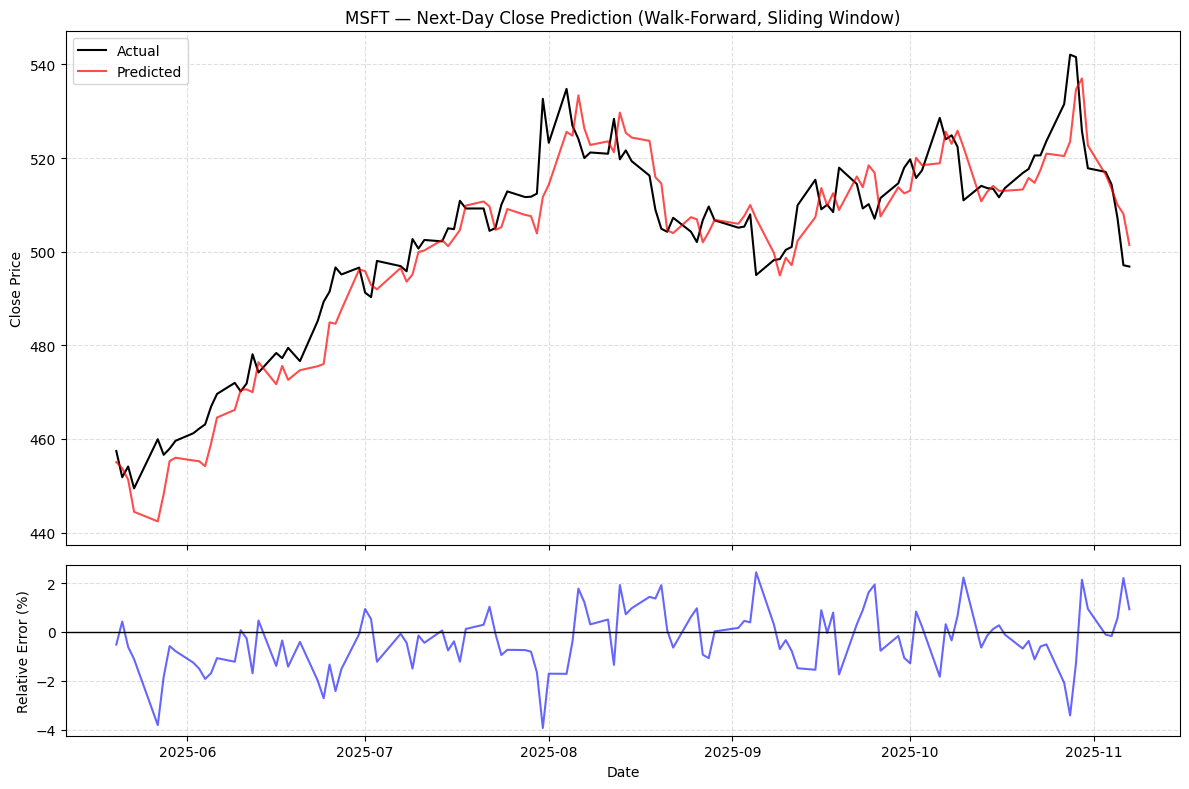

In [19]:
X, y, target_dates, feature_dates = create_features(data, lag, use_ta=True)

results, metrics = walk_forward_sliding_window(
    X, y, target_dates,
    train_window=train_window,
    step=1,
    params=study_mape.best_params,
)

print(f"Objective {objective}")
print("\nWalk-forward metrics with best params:")
print(metrics)

plot_walk_forward_results(results, ticker)

### Combined optimizing objective: MAPE + DA

In [20]:
alpha = 0.3
objective = 'composite'

study_combo = optuna_xgb(
    data, 
    lag=lag, 
    train_window=train_window, 
    n_trials=50, 
    use_ta=True, 
    metric=objective,
    alpha=alpha
)

[I 2025-11-10 15:21:46,342] A new study created in memory with name: no-name-d375a97e-bc6a-4cf8-a436-df483a42fbe8
[I 2025-11-10 15:23:08,044] Trial 0 finished with value: 0.819030385918235 and parameters: {'n_estimators': 400, 'learning_rate': 0.07385576938658288, 'max_depth': 8, 'subsample': 0.6828265396634288, 'colsample_bytree': 0.8001310634525958, 'reg_alpha': 0.649248037229731, 'reg_lambda': 0.42907503564818317}. Best is trial 0 with value: 0.819030385918235.


MAE: 4.881, MAPE: 0.973%, R²: 0.91, DA: 51.26%


[I 2025-11-10 15:24:27,032] Trial 1 finished with value: 1.0120431652330208 and parameters: {'n_estimators': 400, 'learning_rate': 0.058977752385889065, 'max_depth': 6, 'subsample': 0.5376750068667595, 'colsample_bytree': 0.8239661076336646, 'reg_alpha': 1.479729509568934, 'reg_lambda': 4.79164007302577}. Best is trial 0 with value: 0.819030385918235.


MAE: 5.730, MAPE: 1.148%, R²: 0.88, DA: 45.38%


[I 2025-11-10 15:26:56,061] Trial 2 finished with value: 1.0157621897686053 and parameters: {'n_estimators': 800, 'learning_rate': 0.029091068252315375, 'max_depth': 6, 'subsample': 0.5393818293611742, 'colsample_bytree': 0.9330573212479989, 'reg_alpha': 4.481615877576303, 'reg_lambda': 3.3886399283246265}. Best is trial 0 with value: 0.819030385918235.


...

MAE: 5.146, MAPE: 1.026%, R²: 0.90, DA: 51.26%


[I 2025-11-10 16:21:19,726] Trial 48 finished with value: 0.8169475899303642 and parameters: {'n_estimators': 400, 'learning_rate': 0.08641248793474293, 'max_depth': 4, 'subsample': 0.8263250502992895, 'colsample_bytree': 0.5251946700544536, 'reg_alpha': 0.20178995310885822, 'reg_lambda': 2.813022557298476}. Best is trial 21 with value: 0.7884002430492361.


MAE: 4.906, MAPE: 0.978%, R²: 0.91, DA: 53.78%


[I 2025-11-10 16:22:29,710] Trial 49 finished with value: 0.8621896240779864 and parameters: {'n_estimators': 600, 'learning_rate': 0.09134205521511364, 'max_depth': 7, 'subsample': 0.8342119468590612, 'colsample_bytree': 0.5252753688945712, 'reg_alpha': 1.251182462763179, 'reg_lambda': 3.09215958243365}. Best is trial 21 with value: 0.7884002430492361.


MAE: 5.123, MAPE: 1.021%, R²: 0.90, DA: 52.94%


In [21]:
print(f"\n=== Optuna optimization finished, objective: {objective} ===")
print("Best objective value:", study_combo.best_value)
print("Best parameters:")
for k, v in study_combo.best_params.items():
    print(f"  {k}: {v}")

best_trial = study_combo.best_trial
print(f"\nBest MAPE: {best_trial.user_attrs['MAPE']:.5f}")
print(f"Best Directional Accuracy: {best_trial.user_attrs['DA']:.2f}%")


=== Optuna optimization finished, objective: composite ===
Best objective value: 0.7884002430492361
Best parameters:
  n_estimators: 600
  learning_rate: 0.08984670248096048
  max_depth: 4
  subsample: 0.8024825217085858
  colsample_bytree: 0.76038004577744
  reg_alpha: 0.0714623460242885
  reg_lambda: 0.9573159588614013

Best MAPE: 0.94722
Best Directional Accuracy: 52.94%


MAE: 5.103, MAPE: 1.017%, R²: 0.90, DA: 50.42%
Combined objective MAPE + DA

Walk-forward metrics with best params:
{'MAE': 5.103233337402344, 'MAPE': np.float64(1.0165818990881224), 'R2': 0.9000239292230126, 'Directional_Accuracy': np.float64(50.42016806722689)}


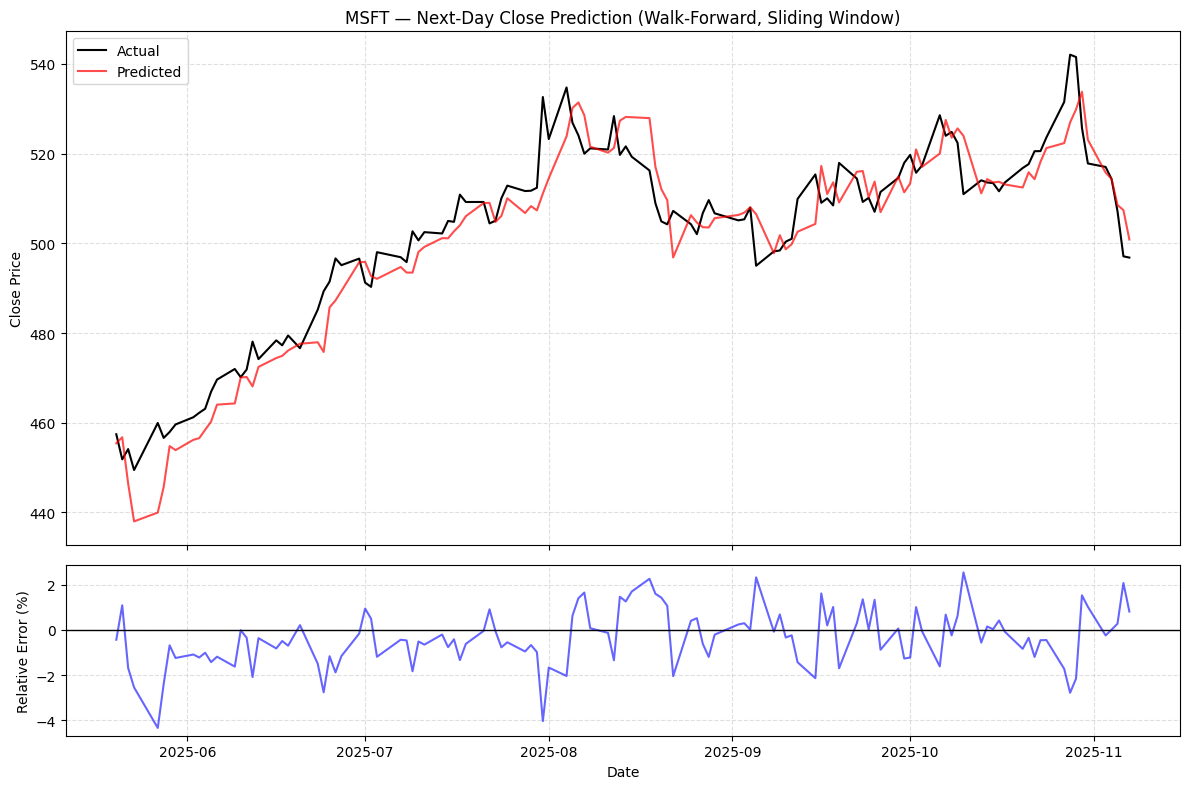

In [22]:
X, y, target_dates, feature_dates = create_features(data, lag, use_ta=True)

results, metrics = walk_forward_sliding_window(
    X, y, target_dates,
    train_window=train_window,
    step=1, # predict daily
    params=study_combo.best_params,
)

print("Combined objective MAPE + DA")
print("\nWalk-forward metrics with best params:")
print(metrics)

plot_walk_forward_results(results, ticker)

### Optimizing objective: DA

In [23]:
objective = 'da'

study_da = optuna_xgb(
    data, 
    lag=lag, 
    train_window=train_window, 
    n_trials=50, 
    use_ta=True, 
    metric=objective,
    alpha=None
)

[I 2025-11-10 16:23:30,216] A new study created in memory with name: no-name-499c3aad-2793-4e1b-b263-db0d6f8967bd
[I 2025-11-10 16:25:04,611] Trial 0 finished with value: -51.26050420168067 and parameters: {'n_estimators': 400, 'learning_rate': 0.07049502523457696, 'max_depth': 8, 'subsample': 0.7345809720143369, 'colsample_bytree': 0.937379722458727, 'reg_alpha': 0.76631221716768, 'reg_lambda': 1.4596293293779943}. Best is trial 0 with value: -51.26050420168067.


MAE: 4.990, MAPE: 0.992%, R²: 0.90, DA: 51.26%


[I 2025-11-10 16:26:31,889] Trial 1 finished with value: -53.78151260504202 and parameters: {'n_estimators': 400, 'learning_rate': 0.013018273688214146, 'max_depth': 6, 'subsample': 0.5720536523940942, 'colsample_bytree': 0.9806016982325142, 'reg_alpha': 1.6241694741771324, 'reg_lambda': 2.9012223511740682}. Best is trial 1 with value: -53.78151260504202.


MAE: 7.087, MAPE: 1.426%, R²: 0.81, DA: 53.78%


[I 2025-11-10 16:27:11,320] Trial 2 finished with value: -54.621848739495796 and parameters: {'n_estimators': 200, 'learning_rate': 0.031652998115839416, 'max_depth': 8, 'subsample': 0.5969163828652009, 'colsample_bytree': 0.5358914210508834, 'reg_alpha': 3.6056317242970293, 'reg_lambda': 0.277086085519051}. Best is trial 2 with value: -54.621848739495796.


...

MAE: 5.655, MAPE: 1.130%, R²: 0.88, DA: 52.94%


[I 2025-11-10 17:40:08,864] Trial 48 finished with value: -52.94117647058824 and parameters: {'n_estimators': 200, 'learning_rate': 0.03130474045834273, 'max_depth': 6, 'subsample': 0.9134572545252673, 'colsample_bytree': 0.6902766772727216, 'reg_alpha': 0.26750296867808776, 'reg_lambda': 4.673536058665703}. Best is trial 46 with value: -58.82352941176471.


MAE: 6.329, MAPE: 1.268%, R²: 0.86, DA: 52.94%


[I 2025-11-10 17:40:46,016] Trial 49 finished with value: -52.10084033613446 and parameters: {'n_estimators': 200, 'learning_rate': 0.05189503761065668, 'max_depth': 5, 'subsample': 0.9490418152318565, 'colsample_bytree': 0.6073506307901974, 'reg_alpha': 0.5976858131941141, 'reg_lambda': 4.17195422796534}. Best is trial 46 with value: -58.82352941176471.


MAE: 5.259, MAPE: 1.048%, R²: 0.90, DA: 52.10%


In [24]:
print(f"\n=== Optuna optimization finished, objective: {objective} ===")
print("Best objective value:", study_da.best_value)
print("Best parameters:")
for k, v in study_da.best_params.items():
    print(f"  {k}: {v}")

best_trial = study_da.best_trial
print(f"\nBest MAPE: {best_trial.user_attrs['MAPE']:.5f}")
print(f"Best Directional Accuracy: {best_trial.user_attrs['DA']:.2f}%")


=== Optuna optimization finished, objective: da ===
Best objective value: -58.82352941176471
Best parameters:
  n_estimators: 200
  learning_rate: 0.03153123906396875
  max_depth: 6
  subsample: 0.8577126959717911
  colsample_bytree: 0.5808119781476816
  reg_alpha: 0.2442846939161989
  reg_lambda: 0.03700009829139335

Best MAPE: 0.98031
Best Directional Accuracy: 58.82%


MAE: 5.014, MAPE: 0.998%, R²: 0.90, DA: 53.78%
Objective DA

Walk-forward metrics with best params:
{'MAE': 5.014222971598307, 'MAPE': np.float64(0.9977468081926995), 'R2': 0.9033298249945324, 'Directional_Accuracy': np.float64(53.78151260504202)}


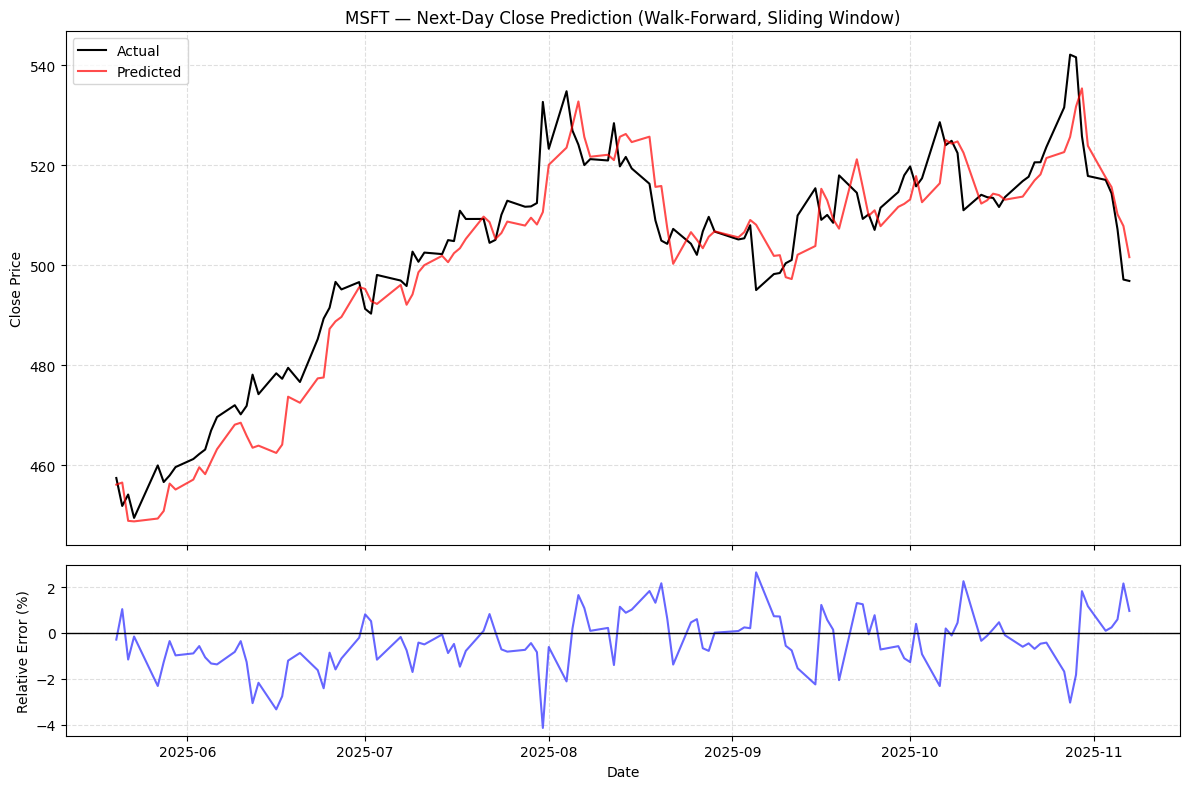

In [27]:
X, y, target_dates, feature_dates = create_features(data, lag, use_ta=True)

results, metrics = walk_forward_sliding_window(
    X, y, target_dates,
    train_window=train_window,
    step=1,
    params=study_da.best_params,
)

print("Objective DA")
print("\nWalk-forward metrics with best params:")
print(metrics)

plot_walk_forward_results(results, ticker)

## Feature importance

In [25]:
def get_feature_names(df, lag):
    base_cols = df.columns.tolist()
    feature_names = []
    for i in range(lag, 0, -1):
        for col in base_cols:
            feature_names.append(f"{col}_t-{i}")
    return feature_names

In [26]:
def get_feature_importance(data, lag, train_window, params, use_ta=True):
    X, y, target_dates, _ = create_features(data, lag, use_ta)
    n_samples = len(X)
    
    # Take the most recent data
    X_train = X[-train_window:]
    y_train = y[-train_window:]
    
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    
    importances = model.feature_importances_

    df_tmp = data.copy()
    if use_ta:
        df_tmp["return"] = df_tmp["close"].pct_change()
        df_tmp["ma_5"] = df_tmp["close"].rolling(5).mean()
        df_tmp["ma_20"] = df_tmp["close"].rolling(20).mean()
        df_tmp["momentum"] = df_tmp["close"] / df_tmp["close"].shift(5) - 1
        df_tmp["volatility"] = df_tmp["return"].rolling(10).std()

        close = df_tmp["close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        rsi = ta.momentum.RSIIndicator(close.squeeze(), window=14).rsi()
        macd = ta.trend.MACD(close.squeeze()).macd()
        bb = ta.volatility.BollingerBands(close.squeeze())

        df_tmp["rsi"] = np.array(rsi).flatten()
        df_tmp["macd"] = np.array(macd).flatten()
        df_tmp["bb_high"] = np.array(bb.bollinger_hband()).flatten()
        df_tmp["bb_low"] = np.array(bb.bollinger_lband()).flatten()
        df_tmp = df_tmp.dropna()

    feature_names = get_feature_names(df_tmp, lag)
    
    sorted_idx_all = np.argsort(importances)[::-1]

    print("\n=== All Feature Importances (Sorted) ===")
    for i in sorted_idx_all:
        print(f"{feature_names[i]}: {importances[i]:.5f}")

    return importances, feature_names

In [14]:
def plot_features(importances, feature_names):
    sorted_idx = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10, 5))
    plt.barh([feature_names[i] for i in sorted_idx[::-1]],
             importances[sorted_idx[::-1]])
    plt.title("Top 20 XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [ ]:
def prune_features_by_importance(data, lag, train_window, params, use_ta=True, threshold=0.001):
    """
    Uses get_feature_importance() to drop low-importance features and re-trains the model.
    """
    importances, feature_names = get_feature_importance(data, lag, train_window, params, use_ta)

    kept_indices = [i for i, imp in enumerate(importances) if imp > threshold]
    kept_features = [feature_names[i] for i in kept_indices]

    print(f"\nKeeping {len(kept_features)} / {len(feature_names)} features (importance > {threshold})")

    X, y, target_dates, _ = create_features(data, lag, use_ta)
    X_reduced = X[:, kept_indices]

    _, metrics = walk_forward_sliding_window(X_reduced, y, target_dates, train_window=train_window, params=params)

    print("\n=== Performance After Feature Pruning ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    return kept_features, metrics


=== All Feature Importances (Sorted) ===
('close', 'msft')_t-1: 0.28706
('high', 'msft')_t-1: 0.17729
('low', 'msft')_t-1: 0.11493
('ma_5', '')_t-1: 0.08367
('close', 'msft')_t-2: 0.07218
('rsi', '')_t-1: 0.03431
('low', 'msft')_t-3: 0.02991
('open', 'msft')_t-1: 0.02765
('ma_5', '')_t-4: 0.01936
('ma_5', '')_t-3: 0.01865
('open', 'msft')_t-3: 0.01346
('bb_high', '')_t-4: 0.01271
('momentum', '')_t-1: 0.01085
('bb_high', '')_t-1: 0.00959
('ma_20', '')_t-4: 0.00860
('volatility', '')_t-4: 0.00578
('volatility', '')_t-2: 0.00490
('momentum', '')_t-4: 0.00472
('bb_high', '')_t-3: 0.00459
('macd', '')_t-4: 0.00375
('volume', 'msft')_t-2: 0.00362
('ma_20', '')_t-3: 0.00344
('high', 'msft')_t-3: 0.00316
('bb_low', '')_t-2: 0.00308
('open', 'msft')_t-2: 0.00306
('bb_high', '')_t-2: 0.00297
('volatility', '')_t-3: 0.00293
('return', '')_t-3: 0.00233
('momentum', '')_t-2: 0.00232
('open', 'msft')_t-4: 0.00222
('low', 'msft')_t-4: 0.00209
('macd', '')_t-3: 0.00189
('volume', 'msft')_t-3: 0.0018

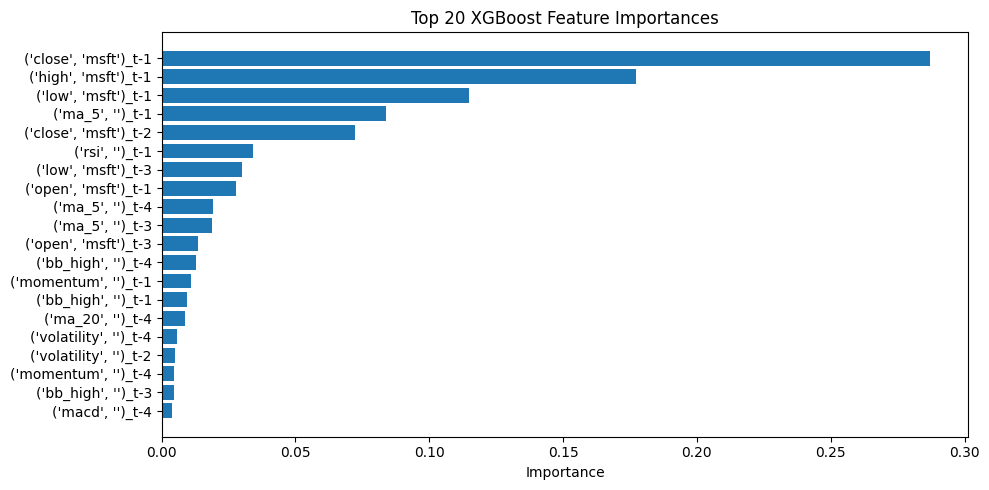

In [28]:
best_params = study_mape.best_params
importances, feature_names = get_feature_importance(data, lag, train_window, best_params, use_ta=True)
plot_features(importances, feature_names)

### Prune features

===Test pruning features===

Threshold = 0.001

=== All Feature Importances (Sorted) ===
('close', 'msft')_t-1: 0.28706
('high', 'msft')_t-1: 0.17729
('low', 'msft')_t-1: 0.11493
('ma_5', '')_t-1: 0.08367
('close', 'msft')_t-2: 0.07218
('rsi', '')_t-1: 0.03431
('low', 'msft')_t-3: 0.02991
('open', 'msft')_t-1: 0.02765
('ma_5', '')_t-4: 0.01936
('ma_5', '')_t-3: 0.01865
('open', 'msft')_t-3: 0.01346
('bb_high', '')_t-4: 0.01271
('momentum', '')_t-1: 0.01085
('bb_high', '')_t-1: 0.00959
('ma_20', '')_t-4: 0.00860
('volatility', '')_t-4: 0.00578
('volatility', '')_t-2: 0.00490
('momentum', '')_t-4: 0.00472
('bb_high', '')_t-3: 0.00459
('macd', '')_t-4: 0.00375
('volume', 'msft')_t-2: 0.00362
('ma_20', '')_t-3: 0.00344
('high', 'msft')_t-3: 0.00316
('bb_low', '')_t-2: 0.00308
('open', 'msft')_t-2: 0.00306
('bb_high', '')_t-2: 0.00297
('volatility', '')_t-3: 0.00293
('return', '')_t-3: 0.00233
('momentum', '')_t-2: 0.00232
('open', 'msft')_t-4: 0.00222
('low', 'msft')_t-4: 0.00209
('macd', 

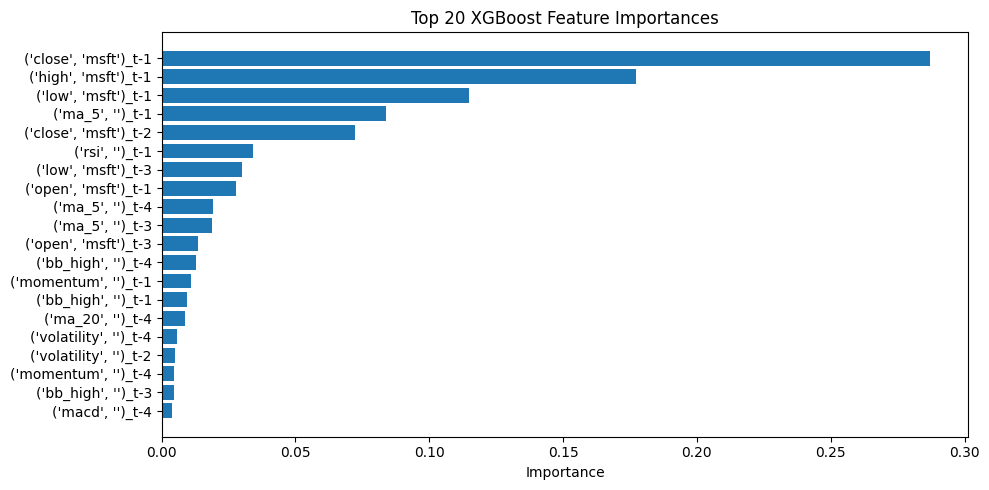

Last available date: 2025-11-07 00:00:00
Predicted close for next day: 496.82
Threshold = 0.005

=== All Feature Importances (Sorted) ===
('close', 'msft')_t-1: 0.28706
('high', 'msft')_t-1: 0.17729
('low', 'msft')_t-1: 0.11493
('ma_5', '')_t-1: 0.08367
('close', 'msft')_t-2: 0.07218
('rsi', '')_t-1: 0.03431
('low', 'msft')_t-3: 0.02991
('open', 'msft')_t-1: 0.02765
('ma_5', '')_t-4: 0.01936
('ma_5', '')_t-3: 0.01865
('open', 'msft')_t-3: 0.01346
('bb_high', '')_t-4: 0.01271
('momentum', '')_t-1: 0.01085
('bb_high', '')_t-1: 0.00959
('ma_20', '')_t-4: 0.00860
('volatility', '')_t-4: 0.00578
('volatility', '')_t-2: 0.00490
('momentum', '')_t-4: 0.00472
('bb_high', '')_t-3: 0.00459
('macd', '')_t-4: 0.00375
('volume', 'msft')_t-2: 0.00362
('ma_20', '')_t-3: 0.00344
('high', 'msft')_t-3: 0.00316
('bb_low', '')_t-2: 0.00308
('open', 'msft')_t-2: 0.00306
('bb_high', '')_t-2: 0.00297
('volatility', '')_t-3: 0.00293
('return', '')_t-3: 0.00233
('momentum', '')_t-2: 0.00232
('open', 'msft')_t-

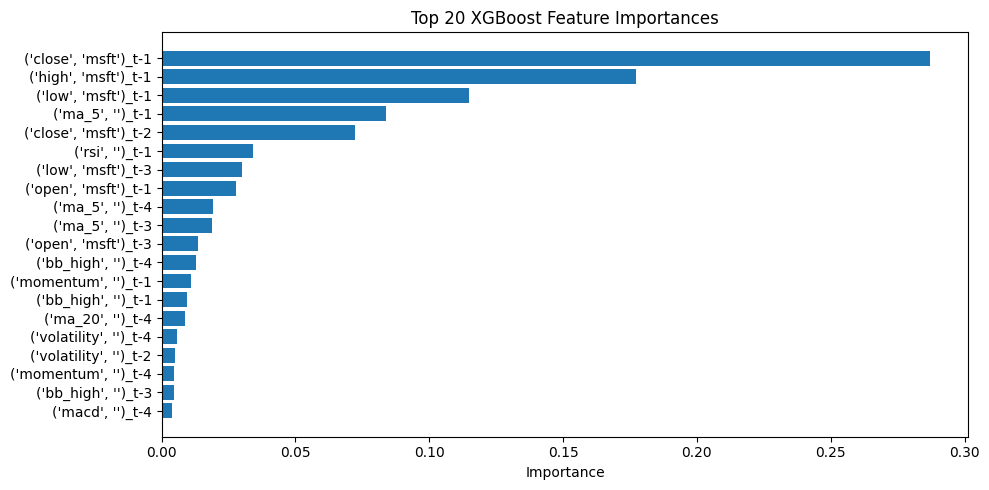

Last available date: 2025-11-07 00:00:00
Predicted close for next day: 496.82
Threshold = 0.01

=== All Feature Importances (Sorted) ===
('close', 'msft')_t-1: 0.28706
('high', 'msft')_t-1: 0.17729
('low', 'msft')_t-1: 0.11493
('ma_5', '')_t-1: 0.08367
('close', 'msft')_t-2: 0.07218
('rsi', '')_t-1: 0.03431
('low', 'msft')_t-3: 0.02991
('open', 'msft')_t-1: 0.02765
('ma_5', '')_t-4: 0.01936
('ma_5', '')_t-3: 0.01865
('open', 'msft')_t-3: 0.01346
('bb_high', '')_t-4: 0.01271
('momentum', '')_t-1: 0.01085
('bb_high', '')_t-1: 0.00959
('ma_20', '')_t-4: 0.00860
('volatility', '')_t-4: 0.00578
('volatility', '')_t-2: 0.00490
('momentum', '')_t-4: 0.00472
('bb_high', '')_t-3: 0.00459
('macd', '')_t-4: 0.00375
('volume', 'msft')_t-2: 0.00362
('ma_20', '')_t-3: 0.00344
('high', 'msft')_t-3: 0.00316
('bb_low', '')_t-2: 0.00308
('open', 'msft')_t-2: 0.00306
('bb_high', '')_t-2: 0.00297
('volatility', '')_t-3: 0.00293
('return', '')_t-3: 0.00233
('momentum', '')_t-2: 0.00232
('open', 'msft')_t-4

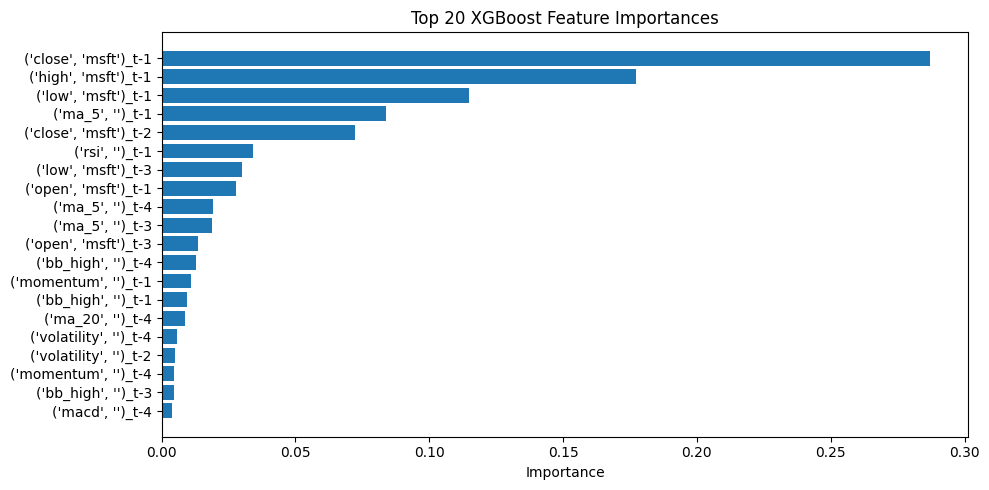

Last available date: 2025-11-07 00:00:00
Predicted close for next day: 496.82
Threshold = 0.02

=== All Feature Importances (Sorted) ===
('close', 'msft')_t-1: 0.28706
('high', 'msft')_t-1: 0.17729
('low', 'msft')_t-1: 0.11493
('ma_5', '')_t-1: 0.08367
('close', 'msft')_t-2: 0.07218
('rsi', '')_t-1: 0.03431
('low', 'msft')_t-3: 0.02991
('open', 'msft')_t-1: 0.02765
('ma_5', '')_t-4: 0.01936
('ma_5', '')_t-3: 0.01865
('open', 'msft')_t-3: 0.01346
('bb_high', '')_t-4: 0.01271
('momentum', '')_t-1: 0.01085
('bb_high', '')_t-1: 0.00959
('ma_20', '')_t-4: 0.00860
('volatility', '')_t-4: 0.00578
('volatility', '')_t-2: 0.00490
('momentum', '')_t-4: 0.00472
('bb_high', '')_t-3: 0.00459
('macd', '')_t-4: 0.00375
('volume', 'msft')_t-2: 0.00362
('ma_20', '')_t-3: 0.00344
('high', 'msft')_t-3: 0.00316
('bb_low', '')_t-2: 0.00308
('open', 'msft')_t-2: 0.00306
('bb_high', '')_t-2: 0.00297
('volatility', '')_t-3: 0.00293
('return', '')_t-3: 0.00233
('momentum', '')_t-2: 0.00232
('open', 'msft')_t-4

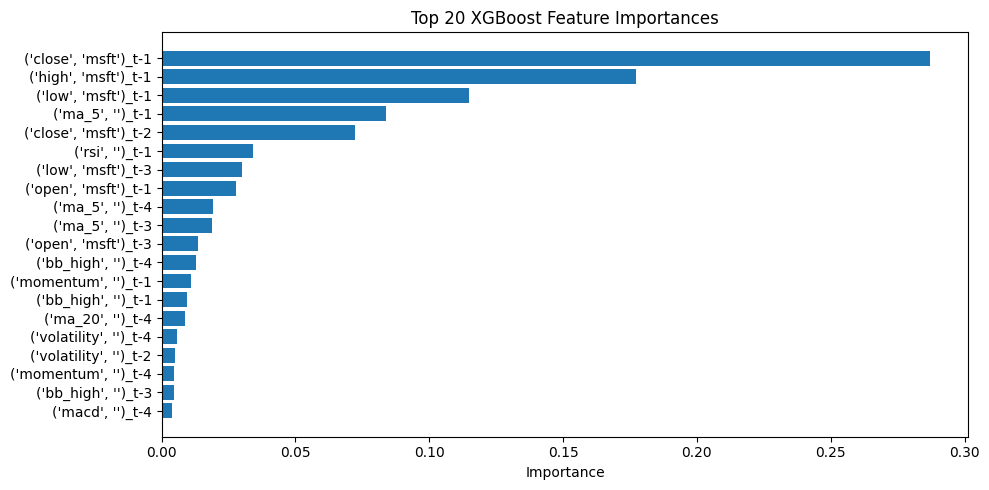

Last available date: 2025-11-07 00:00:00
Predicted close for next day: 496.82


In [30]:
thresholds = [0.001, 0.005, 0.01, 0.02]

print("===Test pruning features===\n")
for threshold in thresholds:
    print(f"Threshold = {threshold}")
    kept_features, metrics = prune_features_by_importance(
        data, lag=lag, train_window=train_window, params=best_params, use_ta=True, threshold=threshold
    )

    # Recreate reduced features
    X, y, target_dates, _ = create_features(data, lag, use_ta=True)
    importances, feature_names = get_feature_importance(data, lag, train_window, best_params, use_ta=True)
    plot_features(importances, feature_names)
    kept_indices = [i for i, name in enumerate(feature_names) if name in kept_features]
    X_reduced = X[:, kept_indices]

    # Train final model on full recent window
    X_train = X_reduced[-train_window:]
    y_train = y[-train_window:]

    final_model = XGBRegressor(**best_params)
    final_model.fit(X_train, y_train)

    next_pred = final_model.predict(X_reduced[-1:].reshape(1, -1))
    last_date = target_dates[-1]

    print(f"Last available date: {last_date}")
    print(f"Predicted close for next day: {next_pred[0]:.2f}")

In [ ]:
def plot_sample(X: np.ndarray, y: np.ndarray, target_dates: np.ndarray, feature_dates: list, 
                sample_idx: int = 0, lag: int = 30, ticker: str = "MSFT"):
    """
    Plots the feature vector (closing prices and volumes) for a given sample,
    and shows the next-day target price.

    Args:
        X (np.ndarray): Feature matrix (n_samples, lookback*2)
        y (np.ndarray): Target array (n_samples,)
        sample_idx (int): Index of the sample to visualize
        lookback (int): Number of past days used in features
        ticker (str): Stock ticker for title
    """
    first_features = X[sample_idx]
    first_target = y[sample_idx]
    target_date = target_dates[sample_idx]
    window_dates = feature_dates[sample_idx]

    closes = first_features[:lag]
    volumes = first_features[lag:]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Close Price', color=color)
    ax1.plot(window_dates, closes, marker='o', color=color, label='Past closes')
    ax1.scatter(target_date, first_target, color='red', label='Next day target')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Volume', color=color)
    ax2.bar(window_dates, volumes, alpha=0.3, color=color, label='Past volumes')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.title(f'{ticker} - Sample {sample_idx} features (closes + volumes) vs. next-day target')
    plt.show()

In [16]:
#plot_sample(X, y, target_dates, feature_dates, sample_idx=0, lag=lag, ticker=ticker)